# **PROJECT 1 — REPRESENTASI DAN PREPROSES DATA**
## KELOMPOK 7 · KAL TIF-D

| No | Nama | NIM |
|----|------|-----|
| 1 | Muhammad Fakhri Aldiansyah | 245150201111049 |
| 2 | Jason Manuel | 245150201111050 |
| 3 | Putri Griselda Sonandi | 245150207111036 |

**Dosen:** Dr. Candra Dewi, S.Kom., M.Sc.  
**Dataset:** Chronic Kidney Disease (CKD)

---
## Alur Notebook
1. Import Library  
2. Load & Inspeksi Data Awal  
3. Data Cleaning (Drop Fitur Noise)  
4. Klasifikasi Tipe Fitur  
5. Exploratory Data Analysis (EDA)  
   - 5.1 Integritas Data (Missing Value)  
   - 5.2 Statistik Deskriptif  
   - 5.3 Distribusi Variabel Target (Class Imbalance)  
   - 5.4 Distribusi Fitur Numerik (Histogram + KDE)  
   - 5.5 Matriks Korelasi Pearson (Seluruh Fitur)  
   - 5.6 Heatmap Top-10 Fitur vs Diagnosis  
   - 5.7 Pair Plot Fitur Utama  
6. Data Preprocessing  
   - 6.1 Penanganan Outlier (IQR Capping)  
   - 6.2 Normalisasi Z-Score (StandardScaler)  
7. Validasi Data Akhir & Simpan Output

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2. Load & Inspeksi Data Awal

In [2]:
df = pd.read_csv('CKD.csv', sep=';')
print(f"Dimensi Data Mentah : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"\nDaftar Kolom ({len(df.columns)} total):")
print(df.columns.tolist())

Dimensi Data Mentah : 1659 baris x 54 kolom

Daftar Kolom (54 total):
['PatientID', 'Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension', 'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury', 'UrinaryTractInfections', 'SystolicBP', 'DiastolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR', 'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium', 'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium', 'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'ACEInhibitors', 'Diuretics', 'NSAIDsUse', 'Statins', 'AntidiabeticMedications', 'Edema', 'FatigueLevels', 'NauseaVomiting', 'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'HeavyMetalsExposure', 'OccupationalExposureChemicals', 'WaterQuality', 'MedicalCheckupsFrequency'

In [3]:
df.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,...,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,...,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


## 3. Data Cleaning — Drop Fitur Noise

Kolom **PatientID** dan **DoctorInCharge** dieliminasi karena:
- Bersifat identifier unik, tidak memiliki nilai prediktif terhadap Diagnosis.
- `DoctorInCharge` bertipe string kategorikal dengan nilai konstan (`"Confidential"`), sehingga tidak memberikan varians informasi apapun.
- Mempertahankan kedua kolom ini hanya akan menambah noise pada algoritma Machine Learning.

In [4]:
COLS_TO_DROP = ['PatientID', 'DoctorInCharge']
df_clean = df.drop(columns=COLS_TO_DROP)

print(f"Dimensi sebelum drop : {df.shape[1]} kolom")
print(f"Dimensi setelah drop : {df_clean.shape[1]} kolom")
print(f"Kolom yang dihapus   : {COLS_TO_DROP}")

Dimensi sebelum drop : 54 kolom
Dimensi setelah drop : 52 kolom
Kolom yang dihapus   : ['PatientID', 'DoctorInCharge']


## 4. Klasifikasi Tipe Fitur

Dataset memiliki dua kelompok fitur selain variabel target:

| Tipe | Kriteria | Perlakuan |
|------|----------|-----------|
| **Biner / Kategorikal** | `nunique == 2`, dikodekan 0/1 (sudah numerik dari sumber) | Dipertahankan tanpa transformasi skala |
| **Kontinu / Numerik** | `nunique > 2` dan bukan `Diagnosis` | Akan dinormalisasi dengan StandardScaler |

> **Catatan:** Kolom seperti `Ethnicity`, `SocioeconomicStatus`, dan `EducationLevel` memiliki lebih dari 2 nilai unik (ordinal), sehingga dimasukkan ke kelompok kontinu untuk ikut dinormalisasi.

In [5]:
binary_cols = [
    col for col in df_clean.columns
    if col != 'Diagnosis' and df_clean[col].nunique() == 2
]

continuous_cols = [
    col for col in df_clean.columns
    if col not in binary_cols and col != 'Diagnosis'
]

print(f"Fitur Biner/Kategorikal  : {len(binary_cols)} fitur")
print(binary_cols)
print()
print(f"Fitur Kontinu/Numerik    : {len(continuous_cols)} fitur")
print(continuous_cols)
print()
print(f"Target Variabel          : Diagnosis")
print(f"Total fitur prediktif    : {len(binary_cols) + len(continuous_cols)} fitur")

Fitur Biner/Kategorikal  : 15 fitur
['Gender', 'Smoking', 'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension', 'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury', 'UrinaryTractInfections', 'ACEInhibitors', 'Diuretics', 'Statins', 'AntidiabeticMedications', 'Edema', 'HeavyMetalsExposure', 'OccupationalExposureChemicals', 'WaterQuality']

Fitur Kontinu/Numerik    : 36 fitur
['Age', 'Ethnicity', 'SocioeconomicStatus', 'EducationLevel', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR', 'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium', 'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium', 'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'NSAIDsUse', 'FatigueLevels', 'NauseaVomiting', 'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'MedicalCheckupsFrequency', 'Medica

## 5. Exploratory Data Analysis (EDA)

### 5.1 Integritas Data — Pengecekan Missing Value

In [6]:
total_missing = df_clean.isnull().sum().sum()
print(f"Total Missing Value di seluruh dataset : {total_missing}")

Total Missing Value di seluruh dataset : 0


In [7]:
missing_per_col = df_clean.isnull().sum()
if missing_per_col.sum() == 0:
    print(" Dataset bersih — tidak ada missing value sama sekali (kelengkapan 100%).")
    print(" Teknik imputasi (mean/median/KNN) tidak diperlukan.")
else:
    print("Kolom dengan missing value:")
    print(missing_per_col[missing_per_col > 0])

 Dataset bersih — tidak ada missing value sama sekali (kelengkapan 100%).
 Teknik imputasi (mean/median/KNN) tidak diperlukan.


### 5.2 Statistik Deskriptif

Tahapan ini memuat Tabel dalam merangkum ukuran statistik utama untuk **seluruh fitur kontinu**:
`count`, `mean`, `std`, `min`, `25%`, `50%` (median), `75%`, dan `max`.

In [8]:
desc = df_clean[continuous_cols].describe().T
desc.columns = ['count', 'mean', 'std', 'min', '25%', 'median (50%)', '75%', 'max']
display(desc.round(3))

,count,mean,std,min,25%,median (50%),75%,max
Age,1659.0,54.441,20.550,20.000,36.000,54.000,72.000,90.000
Ethnicity,1659.0,0.713,1.000,0.000,0.000,0.000,1.000,3.000
SocioeconomicStatus,1659.0,0.978,0.777,0.000,0.000,1.000,2.000,2.000
EducationLevel,1659.0,1.693,0.911,0.000,1.000,2.000,2.000,3.000
BMI,1659.0,27.620,7.289,15.034,21.471,27.652,34.016,39.994
AlcoholConsumption,1659.0,9.970,5.799,0.022,5.051,9.952,14.967,19.993
PhysicalActivity,1659.0,5.024,2.866,0.001,2.555,5.072,7.461,9.998
DietQuality,1659.0,5.029,2.866,0.002,2.558,4.990,7.428,9.999
SleepQuality,1659.0,6.942,1.704,4.001,5.487,6.933,8.346,9.984
SystolicBP,1659.0,134.392,25.768,90.000,113.000,134.000,157.000,179.000


**Interpretasi statistik deskriptif:**
- **Age**: Rata-rata ~54 tahun, distribusi cukup merata (min 21, max 90).
- **BMI**: Rata-rata ~27.6, mayoritas sampel berada di rentang *overweight* ringan.
- **SerumCreatinine**: Rata-rata ~2.8 mg/dL dengan std tinggi → distribusi menceng kanan (*positively skewed*), mengindikasikan variasi kondisi ginjal yang besar.
- **GFR**: Semakin rendah nilai GFR, semakin buruk fungsi ginjal,  variasi tinggi menunjukkan spektrum keparahan yang lebar dalam dataset.
- **HbA1c & FastingBloodSugar**: Berkaitan dengan kontrol gula darah, relevan sebagai faktor risiko CKD pada penderita diabetes.
- **BUNLevels**: Blood Urea Nitrogen, indikator fungsi ginjal yaitu nilai ekstrem di sisi kanan konsisten dengan adanya pasien CKD parah.

### 5.3 Distribusi Variabel Target — Class Imbalance

`Diagnosis`: 0 = Negatif CKD, 1 = Positif CKD

In [9]:
diagnosis_counts = df_clean['Diagnosis'].value_counts().sort_index()
imbalance_ratio = diagnosis_counts[1] / diagnosis_counts[0]

print("=== Distribusi Kelas Target ===")
print(f"Kelas 0 (Negatif CKD) : {diagnosis_counts[0]} pasien ({diagnosis_counts[0]/len(df_clean)*100:.1f}%)")
print(f"Kelas 1 (Positif CKD) : {diagnosis_counts[1]} pasien ({diagnosis_counts[1]/len(df_clean)*100:.1f}%)")
print(f"Rasio Imbalance (1:0) : {imbalance_ratio:.1f}x")
print()
print("Class Imbalance terdeteksi. Pada evaluasi model nanti perlu F1-Score,")
print("Precision, dan Recall. Artinya bukan hanya Accuracy sebagai metrik tunggal.")

=== Distribusi Kelas Target ===
Kelas 0 (Negatif CKD) : 135 pasien (8.1%)
Kelas 1 (Positif CKD) : 1524 pasien (91.9%)
Rasio Imbalance (1:0) : 11.3x

Class Imbalance terdeteksi. Pada evaluasi model nanti perlu F1-Score,
Precision, dan Recall. Artinya bukan hanya Accuracy sebagai metrik tunggal.


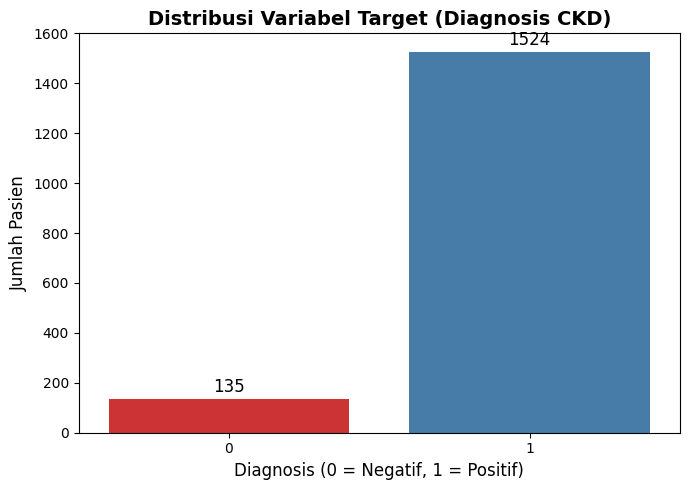

In [10]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_clean, x='Diagnosis', palette='Set1', order=[0, 1])
plt.title('Distribusi Variabel Target (Diagnosis CKD)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis (0 = Negatif, 1 = Positif)', fontsize=12)
plt.ylabel('Jumlah Pasien', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

### 5.4 Distribusi Fitur Numerik — Histogram + KDE

Tiga fitur kami pilih sebagai representasi:
- **Age**: Demografis, distribusi simetris
- **BMI**: Antropometri, distribusi mendekati normal
- **SerumCreatinine**: Biokimia ginjal, distribusi menceng kanan

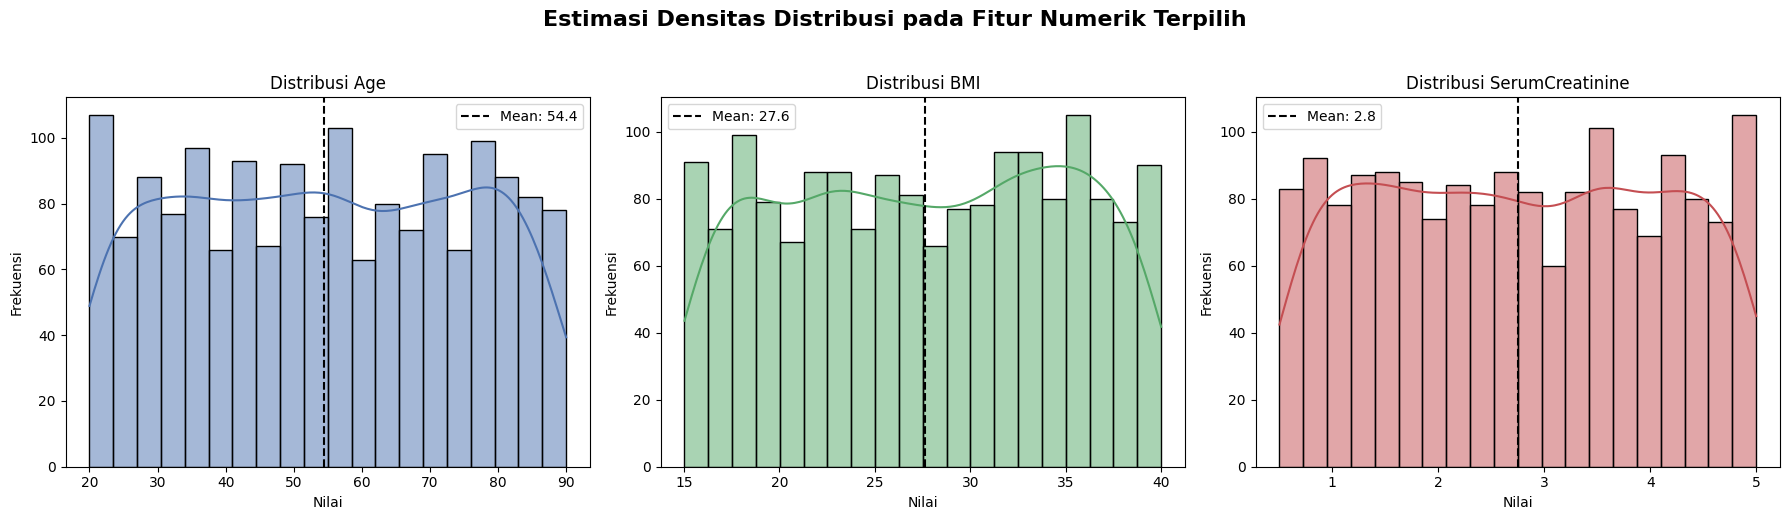

In [11]:
sample_features = ['Age', 'BMI', 'SerumCreatinine']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Estimasi Densitas Distribusi pada Fitur Numerik Terpilih',
             fontsize=16, fontweight='bold', y=1.03)

colors = ['#4C72B0', '#55A868', '#C44E52']
for i, col in enumerate(sample_features):
    sns.histplot(data=df_clean, x=col, kde=True, ax=axes[i],
                 color=colors[i], bins=20)
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
    axes[i].set_xlabel('Nilai', fontsize=10)
    mean_val = df_clean[col].mean()
    axes[i].axvline(mean_val, color='black', linestyle='dashed',
                    linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

### 5.5 Matriks Korelasi Pearson — Seluruh Fitur

Heatmap ini menampilkan korelasi linear berpasangan untuk seluruh 52 fitur prediktif + Diagnosis.

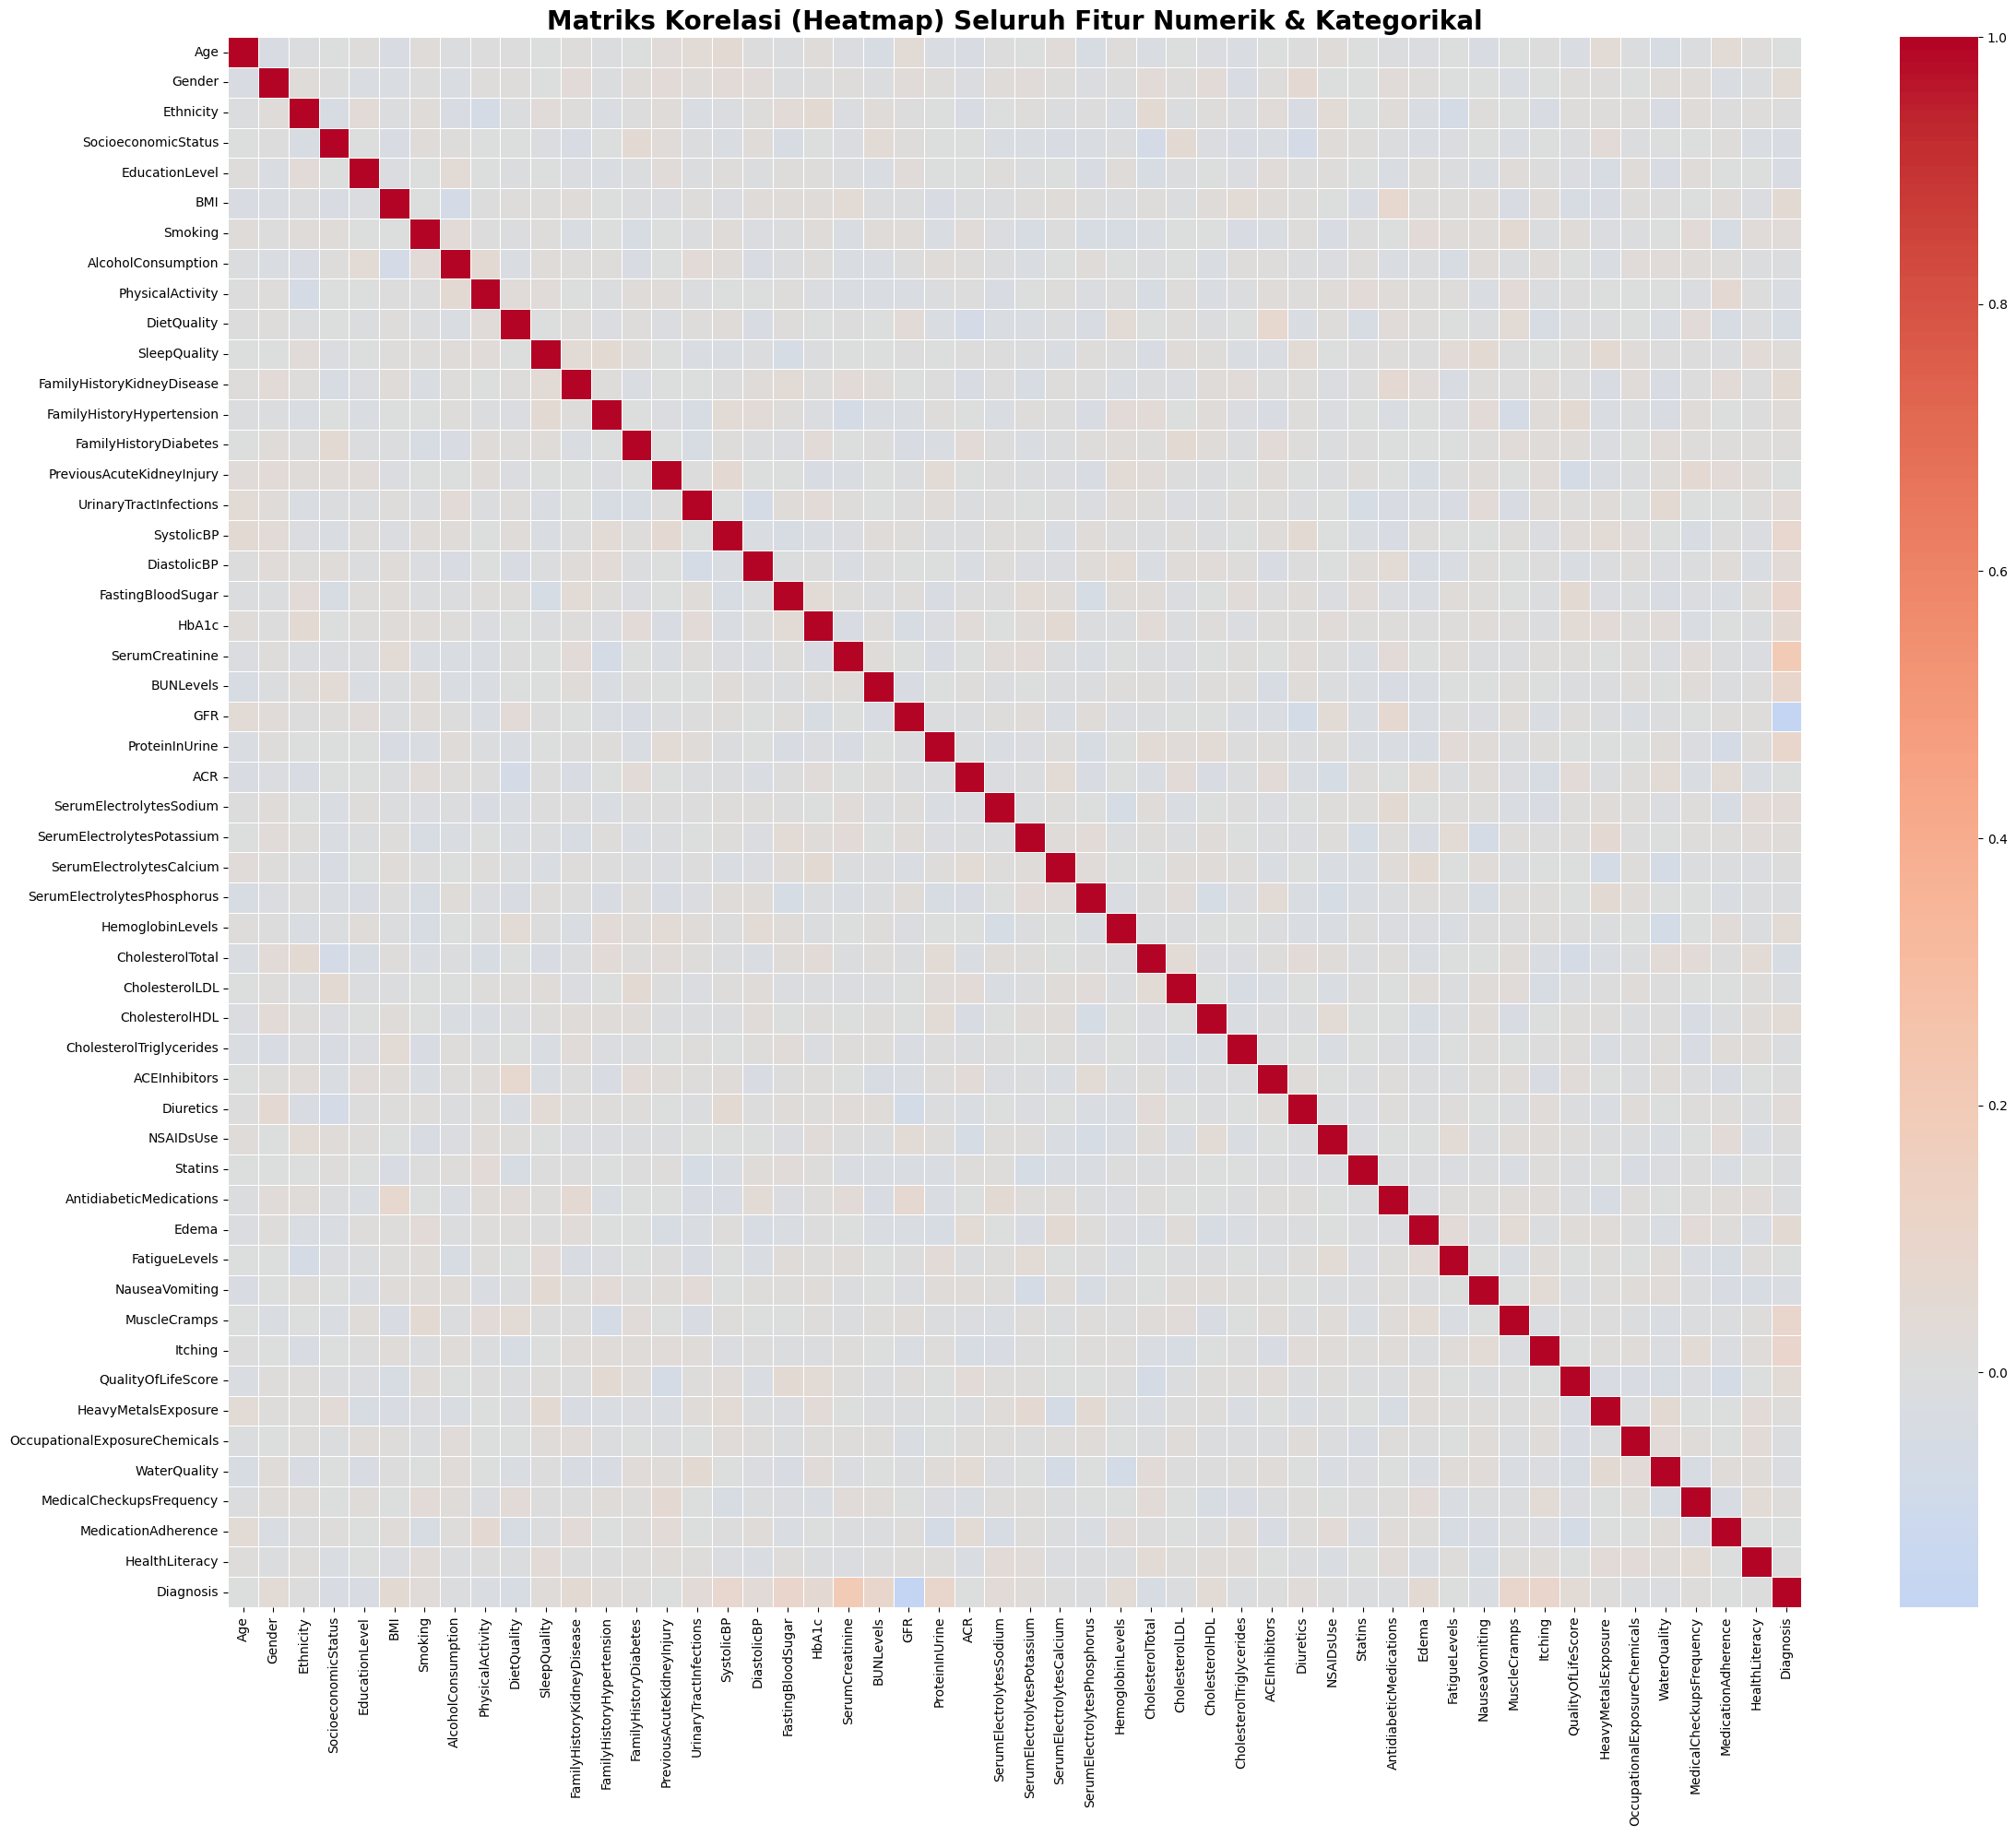

In [12]:
corr_matrix = df_clean.corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Matriks Korelasi (Heatmap) Seluruh Fitur Numerik & Kategorikal',
          fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
print("Observasi:")
print("- Mayoritas pasangan fitur memiliki korelasi rendah (mendekati 0).")
print("- Area dengan warna lebih pekat (di luar diagonal) mengindikasikan korelasi")
print("  sedang-tinggi pada fitur satu domain klinis yang sama.")
print("- Potensi multikolinearitas: SystolicBP DiastolicBP, CholesterolTotal↔LDL/HDL/Triglycerides.")

Observasi:
- Mayoritas pasangan fitur memiliki korelasi rendah (mendekati 0).
- Area dengan warna lebih pekat (di luar diagonal) mengindikasikan korelasi
  sedang-tinggi pada fitur satu domain klinis yang sama.
- Potensi multikolinearitas: SystolicBP DiastolicBP, CholesterolTotal↔LDL/HDL/Triglycerides.


### 5.6 Heatmap Top-10 Fitur Berkorelasi dengan Diagnosis

Mengidentifikasi fitur prediktif paling relevan berdasarkan nilai absolut korelasi Pearson terhadap `Diagnosis`.

In [14]:
print("=== TOP 10 FITUR PALING BERKORELASI DENGAN DIAGNOSIS ===")
top_corr = corr_matrix['Diagnosis'].abs().sort_values(ascending=False).head(11)
top_corr_display = corr_matrix['Diagnosis'].sort_values(key=abs, ascending=False).head(11)
print(top_corr_display.to_string())

=== TOP 10 FITUR PALING BERKORELASI DENGAN DIAGNOSIS ===
Diagnosis            1.000000
SerumCreatinine      0.201125
GFR                 -0.175988
Itching              0.100652
FastingBloodSugar    0.095694
MuscleCramps         0.094811
BUNLevels            0.093097
ProteinInUrine       0.090014
SystolicBP           0.083528
HbA1c                0.059999
BMI                  0.055222


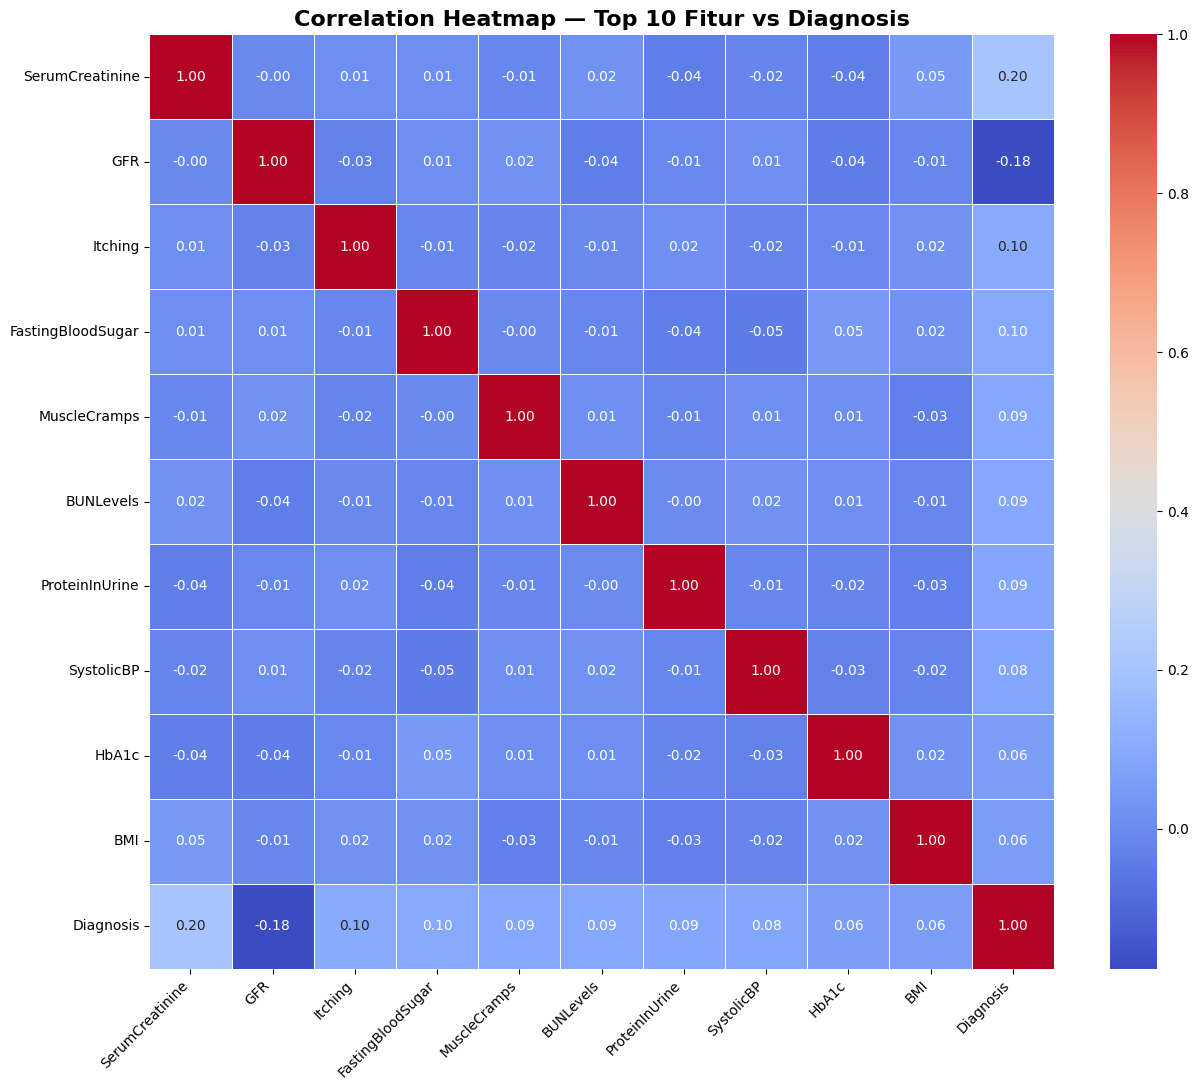

In [15]:
top_10_names = top_corr.index.tolist()
if 'Diagnosis' in top_10_names:
    top_10_names.remove('Diagnosis')

features_for_heatmap = top_10_names + ['Diagnosis']
corr_top = df_clean[features_for_heatmap].corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr_top, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap — Top 10 Fitur vs Diagnosis', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
print("Interpretasi:")
print("- SerumCreatinine memiliki korelasi absolut tertinggi terhadap Diagnosis.")
print("- GFR, Itching, FastingBloodSugar, MuscleCramps, BUNLevels, ProteinInUrine")
print("  juga menunjukkan hubungan yang relevan secara klinis.")
print("- Fitur-fitur ini menjadi kandidat prediktor utama pada tahap modeling selanjutnya.")

Interpretasi:
- SerumCreatinine memiliki korelasi absolut tertinggi terhadap Diagnosis.
- GFR, Itching, FastingBloodSugar, MuscleCramps, BUNLevels, ProteinInUrine
  juga menunjukkan hubungan yang relevan secara klinis.
- Fitur-fitur ini menjadi kandidat prediktor utama pada tahap modeling selanjutnya.


### 5.7 Pair Plot — Fitur Utama berdasarkan Diagnosis

Visualisasi multivariat untuk melihat pola separasi antar kelas pada fitur-fitur kunci.

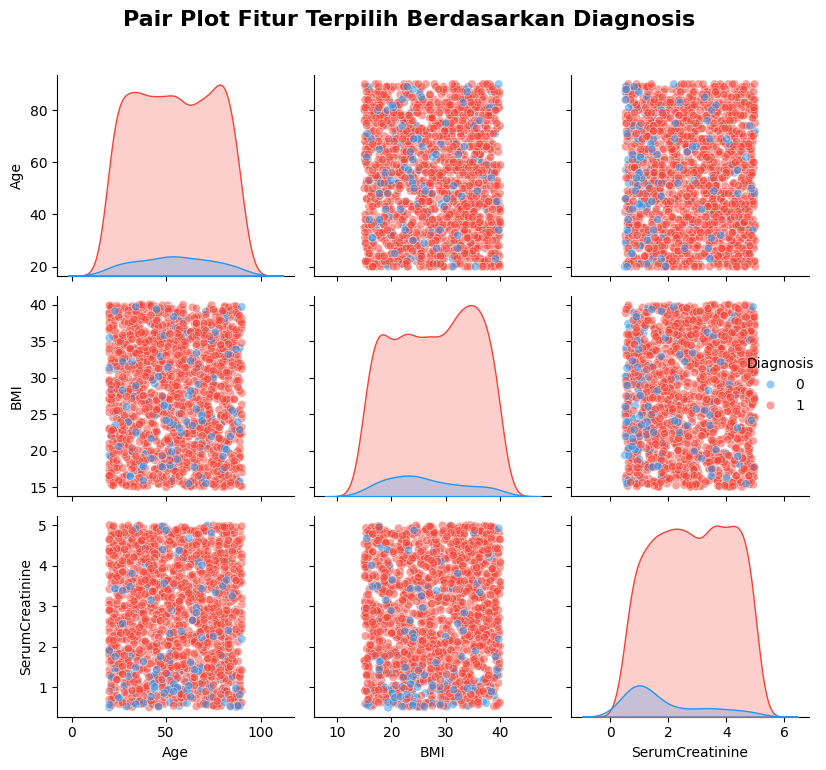

In [17]:
pairplot_cols = ['Age', 'BMI', 'SerumCreatinine', 'Diagnosis']

g = sns.pairplot(df_clean[pairplot_cols], hue='Diagnosis',
                 palette={0: '#2196F3', 1: '#F44336'},
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pair Plot Fitur Terpilih Berdasarkan Diagnosis',
               y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
print("Observasi:")
print("- Scatter plot SerumCreatinine vs fitur lain menunjukkan separasi kelas yang terlihat.")
print("- Pasien positif CKD (merah) cenderung memiliki SerumCreatinine lebih tinggi.")
print("- Age dan BMI menunjukkan overlap yang lebih besar antar kelas.")

Observasi:
- Scatter plot SerumCreatinine vs fitur lain menunjukkan separasi kelas yang terlihat.
- Pasien positif CKD (merah) cenderung memiliki SerumCreatinine lebih tinggi.
- Age dan BMI menunjukkan overlap yang lebih besar antar kelas.


## 6. Data Preprocessing

### 6.1 Penanganan Outlier — IQR Capping

**Metode:** IQR Capping (Winsorization)
- Nilai di bawah `Q1 - 1.5×IQR` -> Diganti dengan nilai batas bawah
- Nilai di atas `Q3 + 1.5×IQR` -> Diganti dengan nilai batas atas

**Alasan memilih Capping (bukan Drop):**  
Data medis mengandung nilai ekstrem yang valid secara klinis. Menghapus baris tersebut akan mengurangi ukuran dataset yang sudah kecil di kelas minoritas (135 pasien negatif). Capping mempertahankan semua observasi sambil meredam dampak nilai ekstrem terhadap model.

In [19]:
df_handled_outliers = df_clean.copy()

In [20]:
outlier_summary = []
for col in continuous_cols:
    Q1 = df_handled_outliers[col].quantile(0.25)
    Q3 = df_handled_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df_handled_outliers[col] < lower) | (df_handled_outliers[col] > upper)).sum()
    df_handled_outliers[col] = df_handled_outliers[col].clip(lower=lower, upper=upper)
    if n_outliers > 0:
        outlier_summary.append({'Fitur': col, 'Jumlah Outlier': n_outliers,
                                 'Lower Bound': round(lower, 3), 'Upper Bound': round(upper, 3)})

In [21]:
print(f"=== Outlier yang Ditangani ===")
df_outlier_summary = pd.DataFrame(outlier_summary).sort_values('Jumlah Outlier', ascending=False)
display(df_outlier_summary.reset_index(drop=True))
print(f"\nTotal fitur dengan outlier : {len(df_outlier_summary)}")
print("Semua outlier berhasil dicap tanpa menghapus baris data.")

=== Outlier yang Ditangani ===


,Fitur,Jumlah Outlier,Lower Bound,Upper Bound
0,Ethnicity,162,-1.5,2.5



Total fitur dengan outlier : 1
Semua outlier berhasil dicap tanpa menghapus baris data.


In [22]:
selected_for_boxplot = ['Age', 'BMI', 'SerumCreatinine']

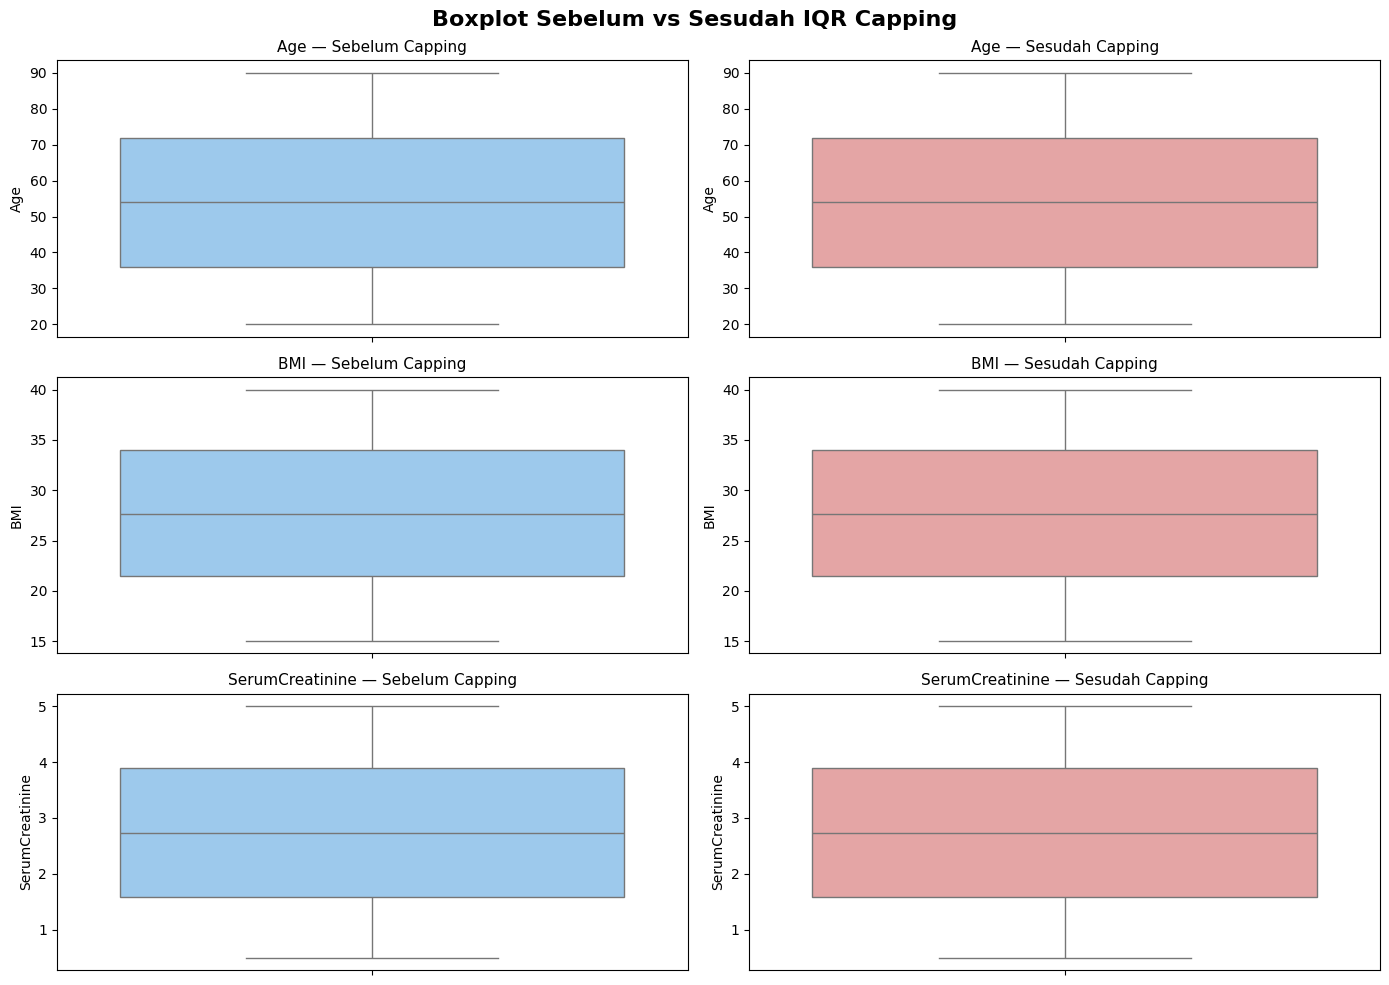

In [23]:
fig, axes = plt.subplots(len(selected_for_boxplot), 2, figsize=(14, 10))
fig.suptitle('Boxplot Sebelum vs Sesudah IQR Capping', fontsize=16, fontweight='bold')

for i, col in enumerate(selected_for_boxplot):
    sns.boxplot(y=df_clean[col], ax=axes[i, 0], color='#90CAF9')
    axes[i, 0].set_title(f'{col} — Sebelum Capping', fontsize=11)
    axes[i, 0].set_ylabel(col)

    sns.boxplot(y=df_handled_outliers[col], ax=axes[i, 1], color='#EF9A9A')
    axes[i, 1].set_title(f'{col} — Sesudah Capping', fontsize=11)
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

In [24]:
print("=== Statistik Deskriptif: Sebelum Capping ===")
display(df_clean[selected_for_boxplot].describe().round(3))

=== Statistik Deskriptif: Sebelum Capping ===


,Age,BMI,SerumCreatinine
count,1659.000,1659.000,1659.000
mean,54.441,27.620,2.753
std,20.550,7.289,1.317
min,20.000,15.034,0.502
25%,36.000,21.471,1.583
50%,54.000,27.652,2.732
75%,72.000,34.016,3.890
max,90.000,39.994,4.999


In [25]:
print("\n=== Statistik Deskriptif: Sesudah Capping ===")
display(df_handled_outliers[selected_for_boxplot].describe().round(3))


=== Statistik Deskriptif: Sesudah Capping ===


,Age,BMI,SerumCreatinine
count,1659.000,1659.000,1659.000
mean,54.441,27.620,2.753
std,20.550,7.289,1.317
min,20.000,15.034,0.502
25%,36.000,21.471,1.583
50%,54.000,27.652,2.732
75%,72.000,34.016,3.890
max,90.000,39.994,4.999


### 6.2 Normalisasi Z-Score — StandardScaler

**Metode:** StandardScaler -> z = (x - μ) / σ

**Alasan:** Fitur kontinu memiliki skala yang sangat berbeda (Age dalam puluhan, ACR dalam ratusan, BUNLevels dalam puluhan). Perbedaan skala ini menyebabkan bias pada algoritma berbasis jarak (SVM, KNN) dan gradient descent. StandardScaler menormalisasi semua fitur kontinu ke mean ≈ 0 dan std ≈ 1.

**Input yang digunakan:** `df_handled_outliers` (data SETELAH outlier ditangani) — bukan `df_clean`.  
Ini memastikan normalisasi tidak terdistorsi oleh nilai ekstrem yang sudah di-cap.

**Fitur biner tidak dinormalisasi** karena sudah dalam skala 0–1 dan maknanya akan hilang jika ditransformasi.

In [26]:
print(f"Fitur yang akan dinormalisasi : {len(continuous_cols)} fitur kontinu")
print(f"Fitur yang dipertahankan      : {len(binary_cols)} fitur biner + 1 target (Diagnosis)")
print()

Fitur yang akan dinormalisasi : 36 fitur kontinu
Fitur yang dipertahankan      : 15 fitur biner + 1 target (Diagnosis)



In [27]:
scaler = StandardScaler()
df_processed = df_handled_outliers.copy()
df_processed[continuous_cols] = scaler.fit_transform(df_handled_outliers[continuous_cols])

In [28]:
sample_cols_norm = ['Age', 'BMI', 'SerumCreatinine']

print("=== Statistik SEBELUM Normalisasi (dari df_handled_outliers) ===")
display(df_handled_outliers[sample_cols_norm].describe().round(3).loc[['mean', 'std', 'min', 'max']])

print("\n=== Statistik SESUDAH Normalisasi (dari df_processed) ===")
display(df_processed[sample_cols_norm].describe().round(3).loc[['mean', 'std', 'min', 'max']])

print("\nInterpretasi:")
print("- Mean mendekati 0 dan Std mendekati 1 pada semua fitur -> normalisasi berhasil.")
print("- Fitur biner (Gender, Smoking, dll.) tidak berubah nilainya.")

=== Statistik SEBELUM Normalisasi (dari df_handled_outliers) ===


,Age,BMI,SerumCreatinine
mean,54.441,27.620,2.753
std,20.550,7.289,1.317
min,20.000,15.034,0.502
max,90.000,39.994,4.999



=== Statistik SESUDAH Normalisasi (dari df_processed) ===


,Age,BMI,SerumCreatinine
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-1.676,-1.727,-1.710
max,1.731,1.698,1.705



Interpretasi:
- Mean mendekati 0 dan Std mendekati 1 pada semua fitur -> normalisasi berhasil.
- Fitur biner (Gender, Smoking, dll.) tidak berubah nilainya.


In [29]:
print("=== Verifikasi Fitur Biner (harus tetap 0/1) ===")
display(df_processed[binary_cols[:5]].describe().round(3).loc[['mean', 'std', 'min', 'max']])

=== Verifikasi Fitur Biner (harus tetap 0/1) ===


,Gender,Smoking,FamilyHistoryKidneyDisease,FamilyHistoryHypertension,FamilyHistoryDiabetes
mean,0.515,0.293,0.141,0.301,0.257
std,0.500,0.455,0.348,0.459,0.437
min,0.000,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000


## 7. Validasi Data Akhir & Simpan Output

In [30]:
print("=== RINGKASAN PIPELINE PREPROCESSING ===")
print(f"{'Step':<5} {'Proses':<40} {'Keterangan'}")
print("-" * 80)
print(f"{'1':<5} {'Load Data':<40} {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"{'2':<5} {'Drop PatientID & DoctorInCharge':<40} {df_clean.shape[1]} kolom tersisa")
print(f"{'3':<5} {'Cek Missing Value':<40} 0 missing → tidak ada imputasi")
print(f"{'4':<5} {'Klasifikasi Fitur':<40} {len(binary_cols)} biner | {len(continuous_cols)} kontinu")
print(f"{'5':<5} {'Outlier Capping (IQR)':<40} {len(df_outlier_summary)} fitur di-cap, 0 baris dihapus")
print(f"{'6':<5} {'Normalisasi StandardScaler':<40} {len(continuous_cols)} fitur kontinu dinormalisasi")
print(f"{'OUT':<5} {'df_processed':<40} {df_processed.shape[0]} baris x {df_processed.shape[1]} kolom")

=== RINGKASAN PIPELINE PREPROCESSING ===
Step  Proses                                   Keterangan
--------------------------------------------------------------------------------
1     Load Data                                1659 baris x 54 kolom
2     Drop PatientID & DoctorInCharge          52 kolom tersisa
3     Cek Missing Value                        0 missing → tidak ada imputasi
4     Klasifikasi Fitur                        15 biner | 36 kontinu
5     Outlier Capping (IQR)                    1 fitur di-cap, 0 baris dihapus
6     Normalisasi StandardScaler               36 fitur kontinu dinormalisasi
OUT   df_processed                             1659 baris x 52 kolom


In [31]:
print("=== STRUKTUR DATA AKHIR ===")
print(df_processed.info())

=== STRUKTUR DATA AKHIR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1659 non-null   float64
 1   Gender                         1659 non-null   int64  
 2   Ethnicity                      1659 non-null   float64
 3   SocioeconomicStatus            1659 non-null   float64
 4   EducationLevel                 1659 non-null   float64
 5   BMI                            1659 non-null   float64
 6   Smoking                        1659 non-null   int64  
 7   AlcoholConsumption             1659 non-null   float64
 8   PhysicalActivity               1659 non-null   float64
 9   DietQuality                    1659 non-null   float64
 10  SleepQuality                   1659 non-null   float64
 11  FamilyHistoryKidneyDisease     1659 non-null   int64  
 12  FamilyHistoryHyperte

In [32]:
print("5 baris pertama data final:")
display(df_processed.head())

5 baris pertama data final:


,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis
0,0.806032,0,-0.743139,-1.259185,0.337031,0.473393,1,-0.835206,-1.168429,-1.671310,...,0.490246,0.868676,0.947049,0,0,1,-0.860001,0.006629,1.629671,1
1,-0.995019,0,-0.743139,0.028724,1.435526,0.284372,1,1.490368,1.170279,0.514741,...,-0.653308,0.618802,-0.345163,0,0,0,1.685111,1.129795,0.695382,1
2,1.244125,1,0.375616,-1.259185,-0.761465,1.341496,1,0.329927,1.599476,-1.020525,...,1.205499,-1.010611,1.550806,0,1,1,-0.499811,0.932782,0.761882,1
3,-0.702956,0,1.494370,-1.259185,-0.761465,0.509112,0,1.043694,-1.610721,0.675720,...,-0.666063,0.702294,1.450425,0,0,0,1.074293,-0.580357,0.511889,1
4,-0.556925,0,0.375616,0.028724,0.337031,-0.534379,0,-0.349434,-1.481089,-0.673929,...,1.617107,-0.521515,-1.598618,0,0,1,-1.502570,-0.382800,-1.278362,1


In [33]:
output_file = 'CKD_Preprocessed_Ready.csv'
df_processed.to_csv(output_file, index=False)
print(f"Data final berhasil disimpan sebagai '{output_file}'")
print(f"Shape: {df_processed.shape[0]} baris x {df_processed.shape[1]} kolom")

Data final berhasil disimpan sebagai 'CKD_Preprocessed_Ready.csv'
Shape: 1659 baris x 52 kolom


# **PROJECT 2 — SELEKSI FITUR**
## KELOMPOK 7 · KAL TIF-D

| No | Nama | NIM |
|----|------|-----|
| 1 | Muhammad Fakhri Aldiansyah | 245150201111049 |
| 2 | Jason Manuel | 245150201111050 |
| 3 | Putri Griselda Sonandi | 245150207111036 |

**Dosen:** Dr. Candra Dewi, S.Kom., M.Sc.  
**Dataset:** Chronic Kidney Disease (CKD)

---
## Alur Notebook
8. Seleksi Fitur - SelectFromModel (Random Forest)  
   - 8.1 Import Library Tambahan
   - 8.2 Persiapan Data untuk Seleksi Fitur
   - 8.3 Pelatihan Random Forest & Ekstraksi Feature Importance
   - 8.4 Visualisasi Feature Importance Seluruh Fitur
   - 8.5 Tuning Threshold untuk Eksplorasi Berbagai Nilai
   - 8.6 Visualisasi Hasil Tuning Threshold
   - 8.7 Seleksi Fitur Final Threshold: mean
   - 8.8 Visualisasi Hasil Seleksi Final
   - 8.9 Dataset Final Pasca Seleksi Fitur

## 8. Seleksi Fitur — SelectFromModel (Random Forest)

### Latar Belakang Metode

a. SelectFromModel memilih fitur berdasarkan skor kepentingan feature importance yang dihasilkan oleh suatu estimator setelah pelatihan. Pada kelompok ini, estimator yang digunakan adalah Random Forest Classifier sebagai salah satu metode tree-based yang robust untuk seleksi fitur. Random Forest menghitung kepentingan fitur menggunakan Mean Decrease in Impurity (MDI) yaitu rata-rata penurunan impurity (Gini impurity) yang dikontribusikan oleh suatu fitur di seluruh pohon keputusan dalam forest. Fitur yang lebih sering digunakan untuk membagi node dan menghasilkan penurunan impurity lebih besar akan mendapat skor importance lebih tinggi.

b. Alasan pemilihan metode ini untuk dataset CKD:
1. Dataset CKD memiliki campuran 15 fitur kategorikal dan 36 fitur kontinu numerik.
2. Metode ini mampu menangkap hubungan non-linear antara fitur dan target, berbeda dengan metode Filter (chi2, F-test) yang hanya mengukur hubungan linear.
3. Random Forest robust terhadap sisa outlier pasca capping dan tidak memerlukan normalisasi (StandardScaler) sebagai prasyarat. Meskipun pada implementasi ini data df_processe yang sudah terstandarisasi tetap digunakan agar konsisten dengan pipeline sebelumnya.
4. Parameter class_weight='balanced' dapat digunakan untuk mengatasi class imbalance sebesar 11,3:1 yang teridentifikasi pada tahap EDA.

c. Kategori metode: Embedded (importance dihitung seiring proses training, bukan sebelum atau sesudah).

### 8.1 Import Library Tambahan

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Library seleksi fitur berhasil diimport.")

Library seleksi fitur berhasil diimport.


### 8.2 Persiapan Data untuk Seleksi Fitur

Data yang digunakan adalah df_processed, hasil akhir pipeline preprocessing (setelah IQR Capping + StandardScaler). Variabel fitur (X) dan target (y) dipisahkan dan diverifikasi bahwa tidak ada nilai kosong yang tersisa.

In [35]:
X = df_processed.drop(columns=['Diagnosis'])
y = df_processed['Diagnosis']
feature_names = X.columns.tolist()

print(f"Shape X (fitur)  : {X.shape}")
print(f"Shape y (target) : {y.shape}")
print(f"Jumlah fitur     : {len(feature_names)}")
print(f"Distribusi target: Positif CKD = {y.sum()} | Negatif CKD = {(y==0).sum()}")
print(f"Rasio imbalance  : {y.sum()/(y==0).sum():.1f}:1")
print(f"Missing value    : {X.isnull().sum().sum()}")

Shape X (fitur)  : (1659, 51)
Shape y (target) : (1659,)
Jumlah fitur     : 51
Distribusi target: Positif CKD = 1524 | Negatif CKD = 135
Rasio imbalance  : 11.3:1
Missing value    : 0


### 8.3 Pelatihan Random Forest & Ekstraksi Feature Importance

Random Forest dilatih dengan konfigurasi:
- n_estimators=200 —> jumlah pohon yang cukup untuk estimasi importance yang stabil
- class_weight='balanced' —> menangani class imbalance 11,3:1 secara otomatis
- max_depth=10 —> membatasi kedalaman pohon untuk mengurangi overfitting
- random_state=42 —> memastikan reproducibility

In [36]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X, y)

importances = rf_model.feature_importances_
std_importances = np.std(
    [tree.feature_importances_ for tree in rf_model.estimators_], axis=0
)

mean_importance   = importances.mean()
median_importance = np.median(importances)

df_importance = pd.DataFrame({
    'Fitur'     : feature_names,
    'Importance': importances,
    'Std'       : std_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== TOP 20 FITUR BERDASARKAN RANDOM FOREST IMPORTANCE ===")
display(df_importance.head(20).round(5))


=== TOP 20 FITUR BERDASARKAN RANDOM FOREST IMPORTANCE ===


,Fitur,Importance,Std
0,SerumCreatinine,0.11110,0.06641
1,GFR,0.08308,0.04912
2,ProteinInUrine,0.05422,0.03683
3,Itching,0.04416,0.03077
4,FastingBloodSugar,0.03815,0.03049
5,MuscleCramps,0.03643,0.02874
6,BUNLevels,0.03520,0.02813
7,SystolicBP,0.02859,0.02554
8,CholesterolHDL,0.02692,0.02320
9,BMI,0.02568,0.02306


### 8.4 Visualisasi Feature Importance Seluruh Fitur

Grafik berikut menampilkan skor feature importance seluruh 51 fitur prediktif beserta error bar yang merepresentasikan standar deviasi kepentingan fitur antar 200 pohon. Error bar kecil berarti estimasi importance stabil dan konsisten.

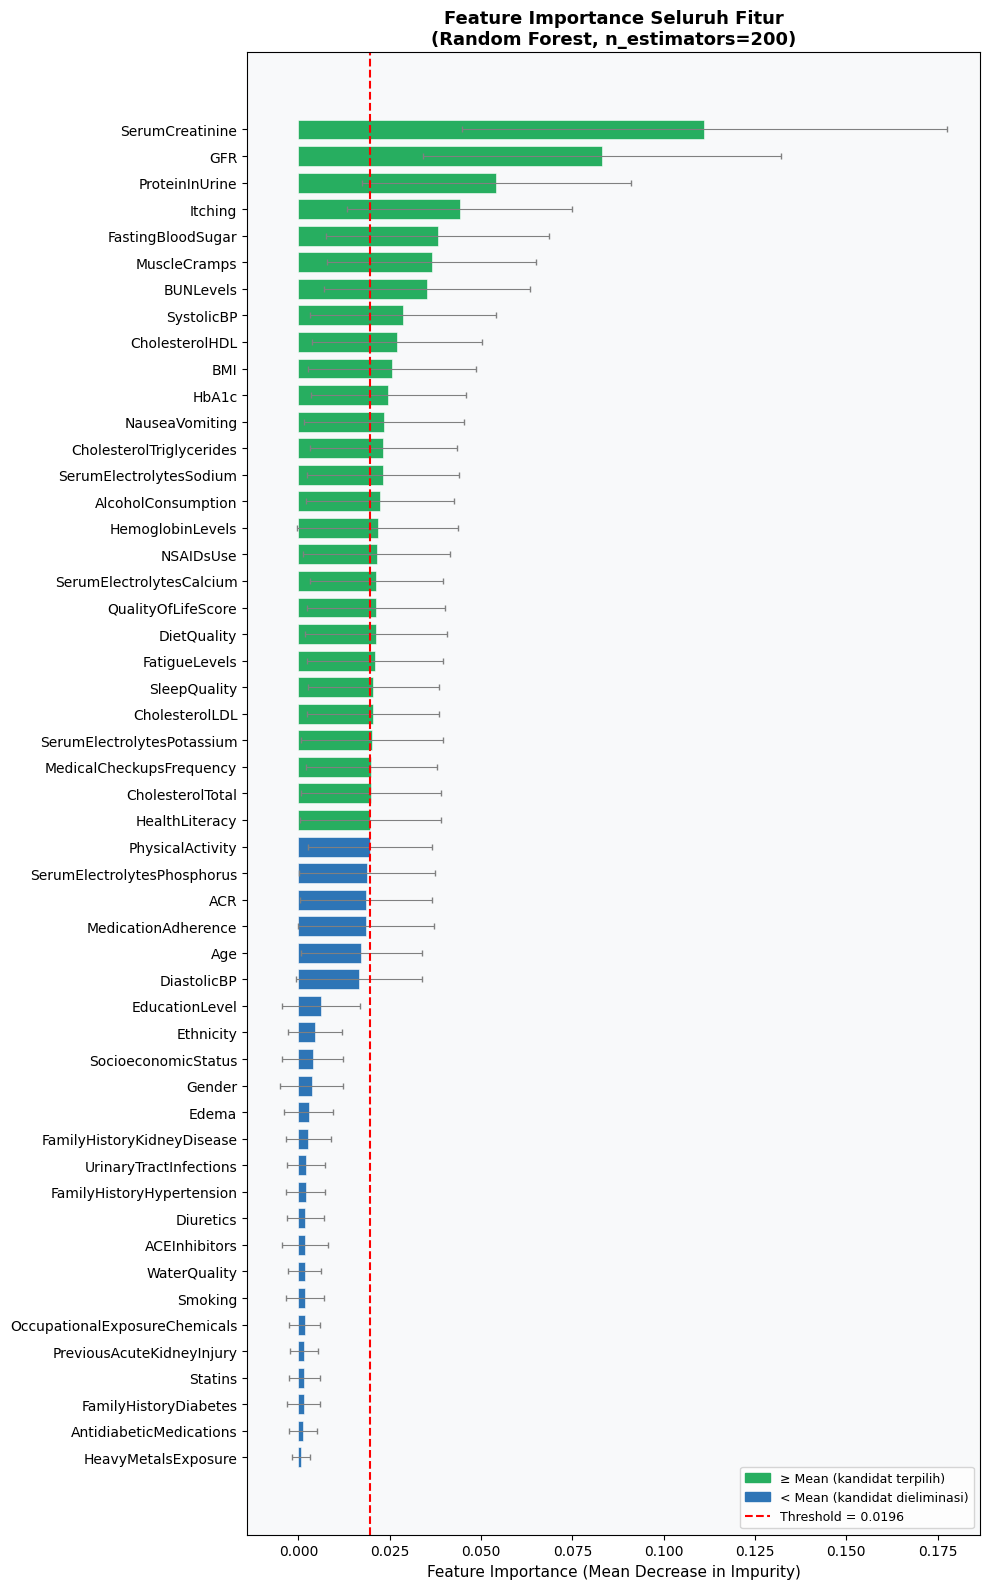

Mean importance (threshold default) : 0.01961
Fitur dengan importance >= mean      : 27
Fitur dengan importance <  mean      : 24


In [37]:
fig, ax = plt.subplots(figsize=(10, 16))

colors_imp = ['#27AE60' if imp > importances.mean() else '#2E75B6'
              for imp in df_importance['Importance']]

ax.barh(
    df_importance['Fitur'][::-1],
    df_importance['Importance'][::-1],
    xerr=df_importance['Std'][::-1],
    color=colors_imp[::-1],
    error_kw={'ecolor': 'gray', 'capsize': 2, 'linewidth': 0.8},
    edgecolor='white', linewidth=0.4, height=0.75
)

mean_importance = importances.mean()
ax.axvline(x=mean_importance, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean Importance = {mean_importance:.4f} (threshold default)')

ax.set_title('Feature Importance Seluruh Fitur\n(Random Forest, n_estimators=200)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_facecolor('#F8F9FA')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#27AE60', label=f'≥ Mean (kandidat terpilih)'),
    Patch(color='#2E75B6', label=f'< Mean (kandidat dieliminasi)'),
    plt.Line2D([0],[0], color='red', linestyle='--', label=f'Threshold = {mean_importance:.4f}')
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print(f"Mean importance (threshold default) : {mean_importance:.5f}")
print(f"Fitur dengan importance >= mean      : {(importances >= mean_importance).sum()}")
print(f"Fitur dengan importance <  mean      : {(importances < mean_importance).sum()}")

### 8.5 Tuning Threshold untuk Eksplorasi Berbagai Nilai

Perlu melakukan tuning/thresholding untuk mengamati bagaimana jumlah fitur terpilih berubah pada kondisi threshold yang berbeda. SelectFromModel mendukung beberapa jenis threshold:

| Threshold | Interpretasi |
|-----------|-------------|
| `'mean'` | Pilih fitur dengan importance ≥ rata-rata semua fitur |
| `'median'` | Pilih fitur dengan importance ≥ median semua fitur |
| `'0.5*mean'` | Threshold lebih longgar (50% dari mean) → lebih banyak fitur terpilih |
| `'2*mean'` | Threshold lebih ketat (200% dari mean) → lebih sedikit fitur terpilih |
| Custom (numerik) | Nilai threshold eksplisit, misalnya 0.01, 0.015, 0.02 |

In [38]:
thresholds_config = [
    ('0.5*mean',     mean_importance * 0.5),
    ('mean',         mean_importance),
    ('median',       median_importance),
    ('1.5*mean',     mean_importance * 1.5),
    ('2*mean',       mean_importance * 2.0),
    ('0.005 (custom)', 0.005),
    ('0.010 (custom)', 0.010),
    ('0.015 (custom)', 0.015),
    ('0.020 (custom)', 0.020),
    ('0.025 (custom)', 0.025),
    ('0.030 (custom)', 0.030),
]

threshold_results = []
for label, thr_val in thresholds_config:
    n_selected   = int((importances >= thr_val).sum())
    n_eliminated = int((importances < thr_val).sum())
    threshold_results.append({
        'Threshold'        : label,
        'Nilai Threshold'  : round(thr_val, 5),
        'Fitur Terpilih'   : n_selected,
        'Fitur Dieliminasi': n_eliminated
    })

df_tuning = pd.DataFrame(threshold_results)
print("=== HASIL TUNING THRESHOLD ===")
display(df_tuning)


=== HASIL TUNING THRESHOLD ===


,Threshold,Nilai Threshold,Fitur Terpilih,Fitur Dieliminasi
0,0.5*mean,0.00980,33,18
1,mean,0.01961,27,24
2,median,0.01983,26,25
3,1.5*mean,0.02941,7,44
4,2*mean,0.03922,4,47
5,0.005 (custom),0.00500,34,17
6,0.010 (custom),0.01000,33,18
7,0.015 (custom),0.01500,33,18
8,0.020 (custom),0.02000,24,27
9,0.025 (custom),0.02500,10,41


**Interpretasi hasil tuning:**

Tabel di atas menunjukkan sensitivitas seleksi fitur terhadap nilai threshold. Threshold mean merupakan titik keseimbangan yang umum digunakan karena memilih fitur yang berkontribusi di atas rata-rata secara intuitif, hal ini berarti hanya fitur yang lebih penting dari rata-rata yang dipertahankan. Threshold yang terlalu rendah (misalnya 0.5 * mean) akan mempertahankan terlalu banyak fitur dan berisiko membawa noise ke model, sementara threshold yang terlalu tinggi (misalnya 2 * mean) sangat agresif dan mungkin membuang fitur yang masih relevan. Pada dataset CKD ini, threshold mean dipilih sebagai konfigurasi final karena menghasilkan jumlah fitur yang reasonable sambil mempertahankan fitur-fitur dengan importance konsisten di atas rata-rata.

### 8.6 Visualisasi Hasil Tuning Threshold

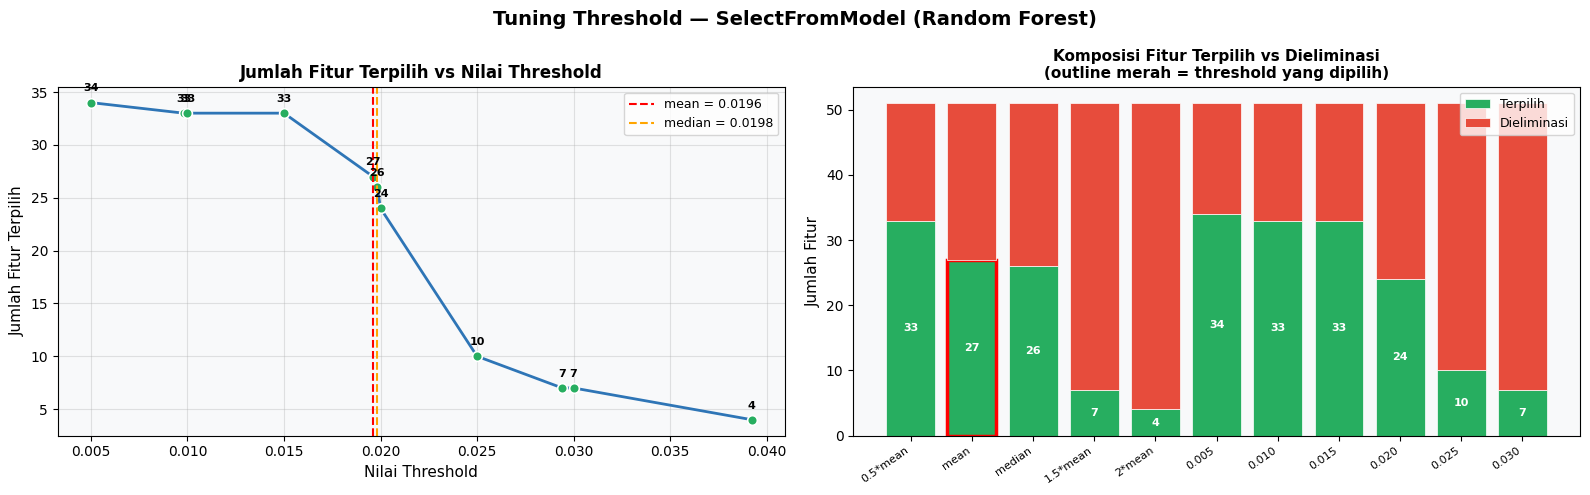

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Tuning Threshold — SelectFromModel (Random Forest)',
             fontsize=14, fontweight='bold')

# Plot 1: Jumlah fitur terpilih vs nilai threshold (semua)
df_plot_all = df_tuning.sort_values('Nilai Threshold')

axes[0].plot(df_plot_all['Nilai Threshold'], df_plot_all['Fitur Terpilih'],
             'o-', color='#2E75B6', linewidth=2, markersize=7,
             markerfacecolor='#27AE60', markeredgecolor='white', markeredgewidth=1.2)

# Threshold mean dan median
mean_row   = df_tuning[df_tuning['Threshold'] == 'mean'].iloc[0]
median_row = df_tuning[df_tuning['Threshold'] == 'median'].iloc[0]

axes[0].axvline(x=mean_row['Nilai Threshold'], color='red',
                linestyle='--', linewidth=1.5, label=f"mean = {mean_row['Nilai Threshold']:.4f}")
axes[0].axvline(x=median_row['Nilai Threshold'], color='orange',
                linestyle='--', linewidth=1.5, label=f"median = {median_row['Nilai Threshold']:.4f}")

for _, row in df_plot_all.iterrows():
    axes[0].annotate(f"{int(row['Fitur Terpilih'])}",
                     (row['Nilai Threshold'], row['Fitur Terpilih']),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8, fontweight='bold')

axes[0].set_xlabel('Nilai Threshold', fontsize=11)
axes[0].set_ylabel('Jumlah Fitur Terpilih', fontsize=11)
axes[0].set_title('Jumlah Fitur Terpilih vs Nilai Threshold', fontsize=12, fontweight='bold')
axes[0].set_facecolor('#F8F9FA')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.35)

# Plot 2: Stacked bar terpilih vs dieliminasi
df_bar = df_tuning.copy()
x_pos = range(len(df_bar))
labels = df_bar['Threshold'].str.replace(' (custom)', '', regex=False)

axes[1].bar(x_pos, df_bar['Fitur Terpilih'], color='#27AE60',
            label='Terpilih', edgecolor='white', linewidth=0.5)
axes[1].bar(x_pos, df_bar['Fitur Dieliminasi'], bottom=df_bar['Fitur Terpilih'],
            color='#E74C3C', label='Dieliminasi', edgecolor='white', linewidth=0.5)

for i, (sel, eli) in enumerate(zip(df_bar['Fitur Terpilih'], df_bar['Fitur Dieliminasi'])):
    axes[1].text(i, sel/2, str(sel), ha='center', va='center',
                 fontsize=8, fontweight='bold', color='white')

# Highlight kolom mean
mean_idx = df_bar[df_bar['Threshold'] == 'mean'].index[0]
axes[1].get_children()[mean_idx].set_edgecolor('red')
axes[1].get_children()[mean_idx].set_linewidth(2.5)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('Jumlah Fitur', fontsize=11)
axes[1].set_title('Komposisi Fitur Terpilih vs Dieliminasi\n(outline merah = threshold yang dipilih)',
                  fontsize=11, fontweight='bold')
axes[1].set_facecolor('#F8F9FA')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 8.7 Seleksi Fitur Final — Threshold: mean

Berdasarkan hasil eksplorasi tuning, threshold mean dipilih sebagai konfigurasi final. Threshold ini secara otomatis dihitung sebagai rata-rata feature importance dari seluruh fitur sehingga bersifat adaptif terhadap distribusi importance yang dihasilkan model.

In [40]:
# SelectFromModel dengan threshold final = mean
selector_final = SelectFromModel(
    RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=10, random_state=42, n_jobs=-1
    ),
    threshold='mean'
)
selector_final.fit(X, y)

X_selected    = selector_final.transform(X)
mask_final    = selector_final.get_support()
threshold_final = selector_final.threshold_

selected_features = [f for f, m in zip(feature_names, mask_final) if m]
dropped_features  = [f for f, m in zip(feature_names, mask_final) if not m]

print("=" * 60)
print(f"SELEKSI FITUR FINAL (threshold = 'mean' = {threshold_final:.5f})")
print("=" * 60)
print(f"  Fitur sebelum seleksi : {len(feature_names)}")
print(f"  Fitur terpilih        : {len(selected_features)}")
print(f"  Fitur dieliminasi     : {len(dropped_features)}")
print()
print("  FITUR TERPILIH:")
for i, f in enumerate(selected_features, 1):
    imp = selector_final.estimator_.feature_importances_[feature_names.index(f)]
    print(f"    {i:2d}. {f:<35} (importance = {imp:.5f})")
print()
print("  FITUR DIELIMINASI (importance < threshold):")
dropped_sorted = sorted(
    dropped_features,
    key=lambda f: selector_final.estimator_.feature_importances_[feature_names.index(f)],
    reverse=True
)
for i, f in enumerate(dropped_sorted, 1):
    imp = selector_final.estimator_.feature_importances_[feature_names.index(f)]
    print(f"    {i:2d}. {f:<35} (importance = {imp:.5f})")


SELEKSI FITUR FINAL (threshold = 'mean' = 0.01961)
  Fitur sebelum seleksi : 51
  Fitur terpilih        : 27
  Fitur dieliminasi     : 24

  FITUR TERPILIH:
     1. BMI                                 (importance = 0.02568)
     2. AlcoholConsumption                  (importance = 0.02223)
     3. DietQuality                         (importance = 0.02116)
     4. SleepQuality                        (importance = 0.02053)
     5. SystolicBP                          (importance = 0.02859)
     6. FastingBloodSugar                   (importance = 0.03815)
     7. HbA1c                               (importance = 0.02461)
     8. SerumCreatinine                     (importance = 0.11110)
     9. BUNLevels                           (importance = 0.03520)
    10. GFR                                 (importance = 0.08308)
    11. ProteinInUrine                      (importance = 0.05422)
    12. SerumElectrolytesSodium             (importance = 0.02322)
    13. SerumElectrolytesPotassium     

### 8.8 Visualisasi Hasil Seleksi Final

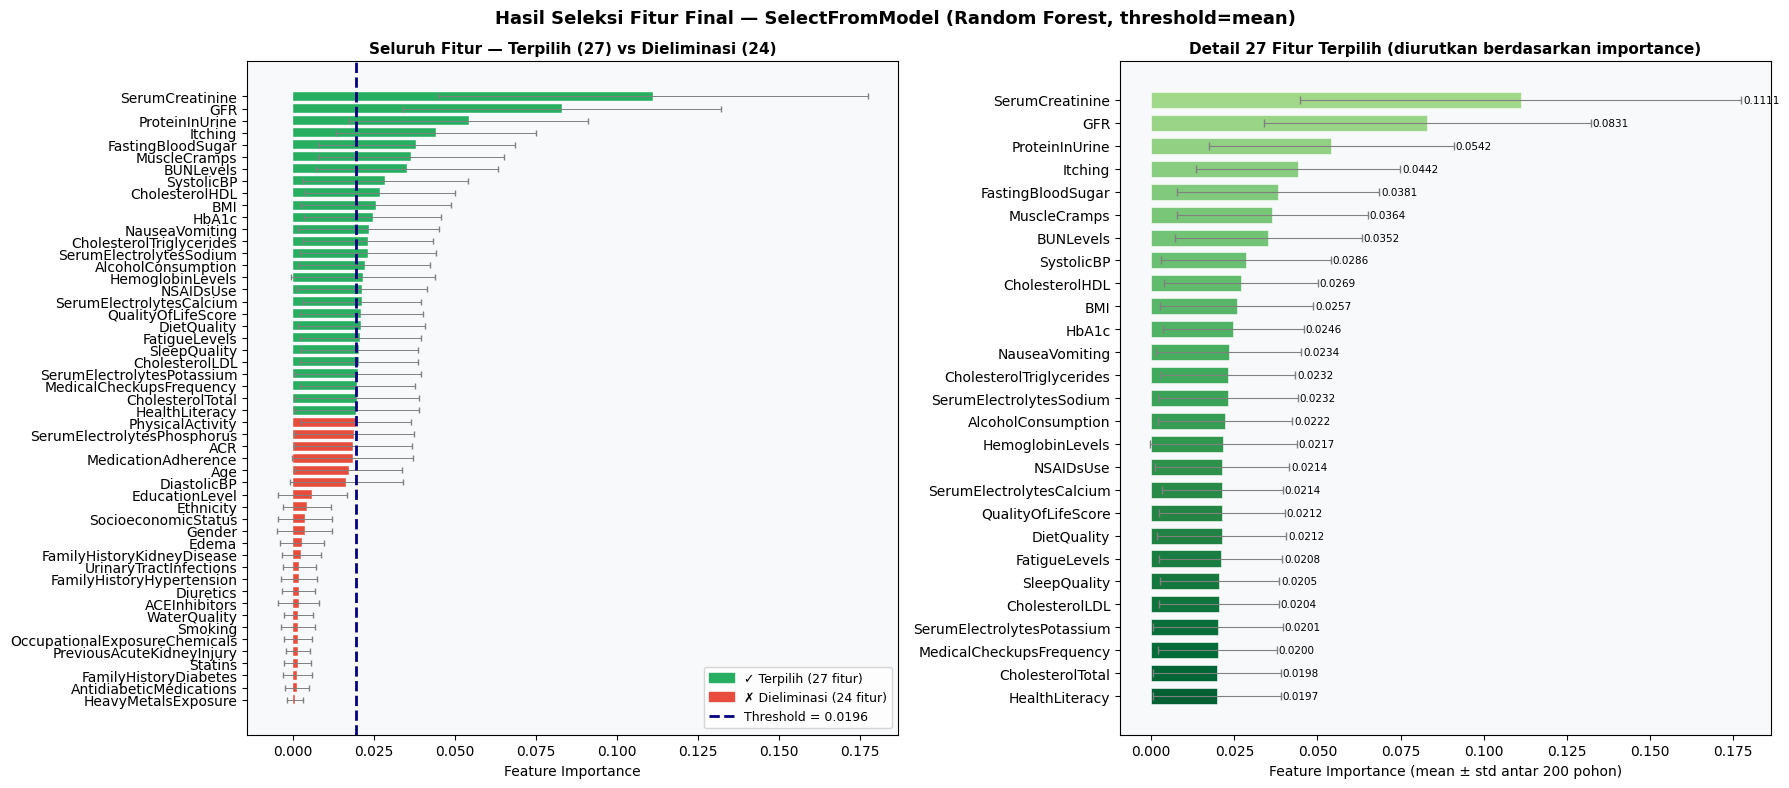

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Hasil Seleksi Fitur Final — SelectFromModel (Random Forest, threshold=mean)',
             fontsize=13, fontweight='bold')

# Plot 1: Semua fitur, highlight terpilih, garis threshold
df_final_plot = df_importance.copy()
df_final_plot['Selected'] = df_final_plot['Fitur'].isin(selected_features)
bar_colors = ['#27AE60' if s else '#E74C3C' for s in df_final_plot['Selected']]

axes[0].barh(
    df_final_plot['Fitur'][::-1],
    df_final_plot['Importance'][::-1],
    xerr=df_final_plot['Std'][::-1],
    color=bar_colors[::-1],
    error_kw={'ecolor': 'gray', 'capsize': 2, 'linewidth': 0.7},
    edgecolor='white', linewidth=0.3, height=0.75
)
axes[0].axvline(x=threshold_final, color='navy', linestyle='--', linewidth=2,
                label=f'Threshold (mean) = {threshold_final:.4f}')
axes[0].set_title(f'Seluruh Fitur — Terpilih ({len(selected_features)}) vs Dieliminasi ({len(dropped_features)})',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Feature Importance', fontsize=10)
axes[0].set_facecolor('#F8F9FA')

from matplotlib.patches import Patch
import matplotlib.lines as mlines
axes[0].legend(handles=[
    Patch(color='#27AE60', label=f'✓ Terpilih ({len(selected_features)} fitur)'),
    Patch(color='#E74C3C', label=f'✗ Dieliminasi ({len(dropped_features)} fitur)'),
    mlines.Line2D([],[],color='navy',linestyle='--',linewidth=2,
                  label=f'Threshold = {threshold_final:.4f}')
], fontsize=9)

# Plot 2: Importance fitur terpilih + error bar (detail)
df_sel_plot = df_importance[df_importance['Fitur'].isin(selected_features)].copy()
df_sel_plot = df_sel_plot.sort_values('Importance', ascending=False).reset_index(drop=True)

cmap_sel = plt.cm.YlGn(np.linspace(0.4, 0.9, len(df_sel_plot)))[::-1]
axes[1].barh(
    df_sel_plot['Fitur'][::-1],
    df_sel_plot['Importance'][::-1],
    xerr=df_sel_plot['Std'][::-1],
    color=cmap_sel,
    error_kw={'ecolor': 'gray', 'capsize': 3, 'linewidth': 0.8},
    edgecolor='white', linewidth=0.4, height=0.7
)
for i, (_, row) in enumerate(df_sel_plot[::-1].iterrows()):
    axes[1].text(row['Importance'] + row['Std'] + 0.0005,
                 i, f"{row['Importance']:.4f}", va='center', fontsize=7.5)

axes[1].set_title(f'Detail {len(selected_features)} Fitur Terpilih (diurutkan berdasarkan importance)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Feature Importance (mean ± std antar 200 pohon)', fontsize=10)
axes[1].set_facecolor('#F8F9FA')

plt.tight_layout()
plt.show()

### 8.9 Dataset Final Pasca Seleksi Fitur

Dataset final yang akan digunakan untuk tahap klasifikasi merupakan subset dari df_processed yang hanya memuat fitur-fitur terpilih beserta variabel target Diagnosis.

In [42]:
df_final_selected = df_processed[selected_features + ['Diagnosis']].copy()

print("=== RINGKASAN PIPELINE SELEKSI FITUR ===")
print(f"{'Step':<5} {'Proses':<45} {'Keterangan'}")
print("-" * 85)
print(f"{'IN':<5} {'Input (df_processed)':<45} {df_processed.shape[0]} baris x {df_processed.shape[1]} kolom")
print(f"{'1':<5} {'Latih RandomForestClassifier':<45} n_estimators=200, class_weight=balanced")
print(f"{'2':<5} {'Hitung Feature Importance (MDI)':<45} {len(feature_names)} fitur dievaluasi")
print(f"{'3':<5} {'Eksplorasi Threshold (tuning)':<45} {len(df_tuning)} kondisi threshold diuji")
print(f"{'4':<5} {'Seleksi Final (threshold=mean)':<45} threshold = {threshold_final:.5f}")
print(f"{'OUT':<5} {'df_final_selected':<45} {df_final_selected.shape[0]} baris x {df_final_selected.shape[1]} kolom")
print()
print(f"Reduksi dimensi: {len(feature_names)} → {len(selected_features)} fitur "
      f"({len(dropped_features)} fitur dieliminasi, "
      f"{len(selected_features)/len(feature_names)*100:.1f}% fitur dipertahankan)")
print()
print("=== STRUKTUR DATASET FINAL ===")
print(df_final_selected.info())

=== RINGKASAN PIPELINE SELEKSI FITUR ===
Step  Proses                                        Keterangan
-------------------------------------------------------------------------------------
IN    Input (df_processed)                          1659 baris x 52 kolom
1     Latih RandomForestClassifier                  n_estimators=200, class_weight=balanced
2     Hitung Feature Importance (MDI)               51 fitur dievaluasi
3     Eksplorasi Threshold (tuning)                 11 kondisi threshold diuji
4     Seleksi Final (threshold=mean)                threshold = 0.01961
OUT   df_final_selected                             1659 baris x 28 kolom

Reduksi dimensi: 51 → 27 fitur (24 fitur dieliminasi, 52.9% fitur dipertahankan)

=== STRUKTUR DATASET FINAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   BMI    

In [43]:
print("5 baris pertama dataset final (fitur terpilih + Diagnosis):")
display(df_final_selected.head())

5 baris pertama dataset final (fitur terpilih + Diagnosis):


,BMI,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,FastingBloodSugar,HbA1c,SerumCreatinine,BUNLevels,GFR,...,CholesterolTriglycerides,NSAIDsUse,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,MedicalCheckupsFrequency,HealthLiteracy,Diagnosis
0,0.473393,-0.835206,-1.671310,-1.682210,-0.830450,-1.642006,1.285161,1.677841,-0.154027,-0.703221,...,-0.126724,-0.156356,-0.501756,1.767706,0.490246,0.868676,0.947049,-0.860001,1.629671,1
1,0.284372,1.490368,0.514741,0.417040,-0.558711,-0.866725,-1.371644,0.306508,0.293655,-0.367645,...,0.305576,1.423967,0.107286,-1.574176,-0.653308,0.618802,-0.345163,1.685111,0.695382,1
2,1.341496,0.329927,-1.020525,-1.496519,0.489425,0.778617,-0.894413,0.717693,0.949690,0.024294,...,0.270192,-0.404492,-0.055700,0.600268,1.205499,-1.010611,1.550806,-0.499811,0.761882,1
3,0.509112,1.043694,0.675720,-0.387434,-0.675170,1.531439,-1.637199,0.087540,-0.437137,-1.119330,...,1.670469,1.000384,1.213975,1.112626,-0.666063,0.702294,1.450425,1.074293,0.511889,1
4,-0.534379,-0.349434,-0.673929,-1.714374,-1.412747,-1.378111,-1.568860,0.920190,-1.199745,-0.349850,...,1.452957,-0.290091,-1.241393,-0.608685,1.617107,-0.521515,-1.598618,-1.502570,-1.278362,1


In [44]:
output_selected = 'CKD_Feature_Selected.csv'
df_final_selected.to_csv(output_selected, index=False)
print(f"Dataset final berhasil disimpan sebagai '{output_selected}'")
print(f"Shape: {df_final_selected.shape[0]} baris x {df_final_selected.shape[1]} kolom")
print(f"Fitur terpilih: {selected_features}")

Dataset final berhasil disimpan sebagai 'CKD_Feature_Selected.csv'
Shape: 1659 baris x 28 kolom
Fitur terpilih: ['BMI', 'AlcoholConsumption', 'DietQuality', 'SleepQuality', 'SystolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR', 'ProteinInUrine', 'SerumElectrolytesSodium', 'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium', 'HemoglobinLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'NSAIDsUse', 'FatigueLevels', 'NauseaVomiting', 'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'MedicalCheckupsFrequency', 'HealthLiteracy']
